## Chest X-Ray Image Preprocessing

## Objective

The objective of this preprocessing stage is to prepare chest X-ray images for deep learning models by enhancing image quality, standardizing input dimensions, and applying data augmentation techniques to improve model generalization.

In [2]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [3]:
TRAIN_DIR = "../data/COVID_19_dataset/train"
VAL_DIR = "../data/COVID_19_dataset/val"
TEST_DIR = "../data/COVID_19_dataset/test"

In [4]:
def apply_clahe(img):

    img = np.array(img)

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2GRAY
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(gray)

    enhanced = cv2.cvtColor(
        enhanced,
        cv2.COLOR_GRAY2RGB
    )

    return enhanced

In [5]:
def get_class_folders(path):

    return [
        d
        for d in os.listdir(path)
        if os.path.isdir(
            os.path.join(path, d)
        )
    ]

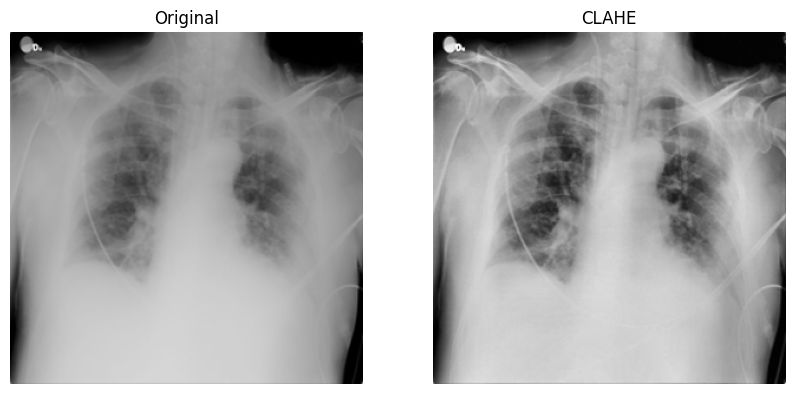

In [6]:
classes = get_class_folders(TRAIN_DIR)
sample_class = classes[0]   
sample_image = os.listdir(
    os.path.join(TRAIN_DIR, sample_class)
)[0]

sample_path = os.path.join(
    TRAIN_DIR,
    sample_class,
    sample_image
)

original = Image.open(sample_path).convert("RGB")

clahe_img = apply_clahe(original)

fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(original)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(clahe_img)
ax[1].set_title("CLAHE")
ax[1].axis("off")

plt.show()

-- Data Augmentation --

To improve model robustness and reduce overfitting, mild geometric augmentations were applied during training.

Augmentation	Parameters

Random Rotation	±5°

Random Translation	3%

Horizontal Flip	Not Applied

Vertical Flip	Not Applied

Large rotations and flips were avoided to preserve anatomical realism and maintain the interpretability of saliency maps generated during explainability analysis.

In [7]:
train_transform = transforms.Compose([

    transforms.Lambda(apply_clahe),

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.RandomAffine(
        degrees=5,
        translate=(0.03,0.03)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5159]*3,
        std=[0.2280]*3
    )
])

In [8]:
val_test_transform = transforms.Compose([

    transforms.Lambda(apply_clahe),

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5159,0.5159,0.5159],
        std=[0.2280,0.2280,0.2280]
    )
])

In [9]:
train_dataset = ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

In [10]:
print(train_dataset.class_to_idx)

{'COVID': 0, 'Normal': 1, 'Viral Pneumonia': 2}


In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [12]:
images, labels = next(iter(train_loader))

print("Image Shape :", images.shape)
print("Label Shape :", labels.shape)

C:\Users\Shantanu Ojha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Image Shape : torch.Size([32, 3, 224, 224])
Label Shape : torch.Size([32])


Normalization

Images were normalized using dataset-specific statistics computed during the exploratory data analysis stage.

Mean:

(0.5159, 0.5159, 0.5159)

Standard Deviation:

(0.2280, 0.2280, 0.2280)

Normalization accelerates convergence and stabilizes training.

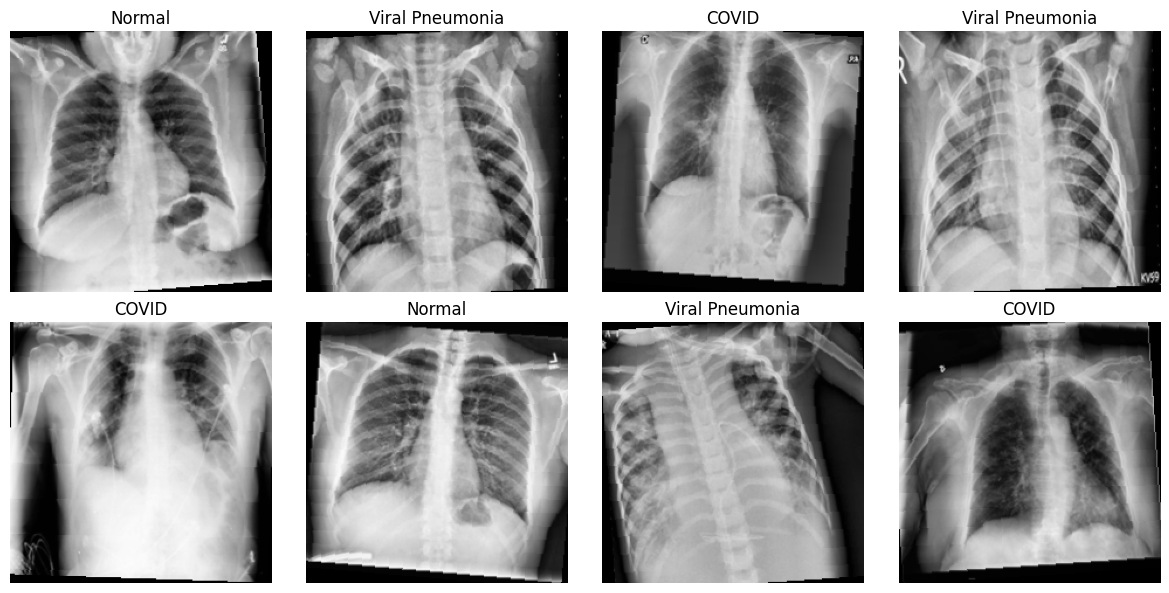

In [13]:
mean = np.array([0.5159, 0.5159, 0.5159])
std = np.array([0.2280, 0.2280, 0.2280])

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12,6)
)

for i, ax in enumerate(axes.flat):

    img = images[i].permute(1,2,0).numpy()

    img = img * std + mean

    img = np.clip(img, 0, 1)

    ax.imshow(img)

    ax.set_title(
        list(train_dataset.class_to_idx.keys())[labels[i]]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
PREPROCESS_CONFIG = {
    "train_dir": TRAIN_DIR,
    "val_dir": VAL_DIR,
    "test_dir": TEST_DIR,
    "batch_size": 32,
    "mean": [0.5159, 0.5159, 0.5159],
    "std": [0.2280, 0.2280, 0.2280]
}

import json

with open("preprocessing_config.json", "w") as f:
    json.dump(PREPROCESS_CONFIG, f)

Conclusion

The preprocessing pipeline successfully enhanced image quality, standardized image dimensions, applied clinically appropriate augmentations, and prepared the dataset for training ResNet50 and Vision Transformer models in subsequent experiments.